In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [14]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [15]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [20]:
df = df.drop(['director', 'cast', 'description'], axis=1)

KeyError: "['director', 'cast', 'description'] not found in axis"

In [18]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [21]:
df.columns

Index(['show_id', 'type', 'title', 'country', 'date_added', 'release_year',
       'rating', 'duration', 'listed_in'],
      dtype='object')

In [22]:
df['country'] = df['country'].fillna('Unknown')

In [23]:
df['rating'] = df['rating'].fillna('Not Rated')

In [25]:
df = df.dropna()

In [26]:
df.isnull().sum()

show_id         0
type            0
title           0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [27]:
df['type'].value_counts()

type
Movie      6128
TV Show    2666
Name: count, dtype: int64

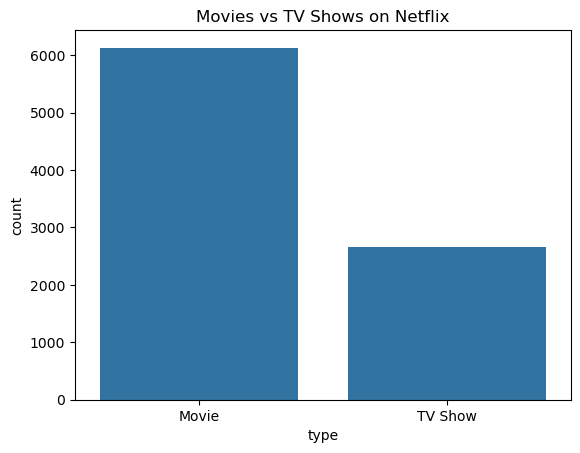

In [28]:
sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows on Netflix')
plt.show()

In [29]:
df['type'].value_counts()

type
Movie      6128
TV Show    2666
Name: count, dtype: int64

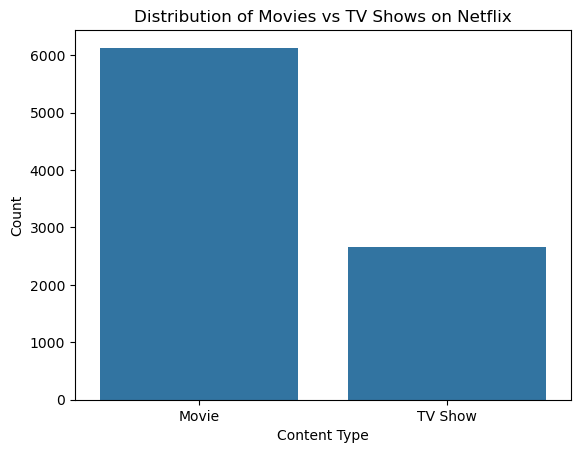

In [30]:
sns.countplot(x='type', data=df)
plt.title('Distribution of Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

In [31]:
df['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1031
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

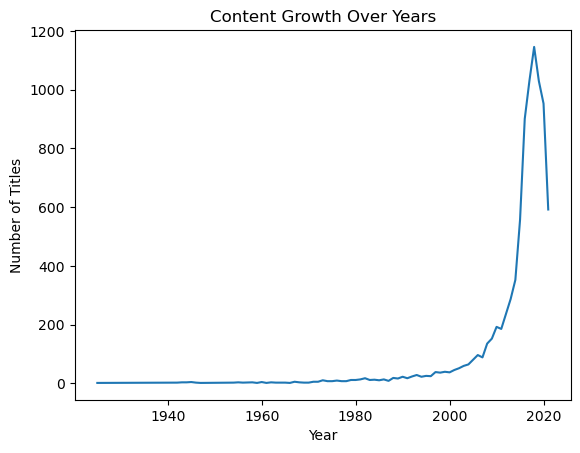

In [32]:
df['release_year'].value_counts().sort_index().plot(kind='line')

plt.title('Content Growth Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

In [33]:
df_genre = df.copy()

df_genre['listed_in'] = df_genre['listed_in'].str.split(',')

df_genre = df_genre.explode('listed_in')

df_genre['listed_in'] = df_genre['listed_in'].str.strip()

In [34]:
df_genre['listed_in'].value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

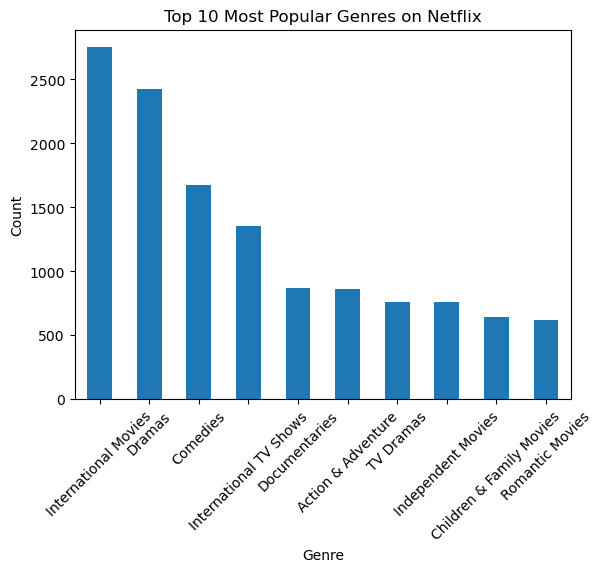

In [35]:
top_genres = df_genre['listed_in'].value_counts().head(10)

top_genres.plot(kind='bar')

plt.title('Top 10 Most Popular Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [36]:
df_country = df.copy()

df_country['country'] = df_country['country'].str.split(',')

df_country = df_country.explode('country')

df_country['country'] = df_country['country'].str.strip()

In [37]:
df_country['country'].value_counts().head(10)

country
United States     3681
India             1046
Unknown            830
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

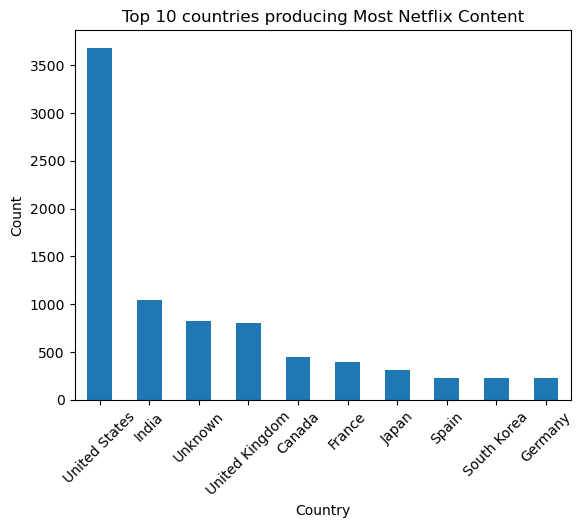

In [38]:
top_country = df_country['country'].value_counts().head(10)

top_country.plot(kind='bar')

plt.title('Top 10 countries producing Most Netflix Content')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

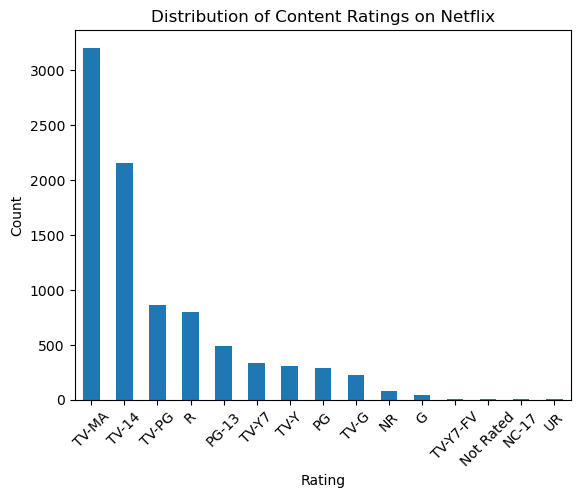

In [39]:
df['rating'].value_counts().plot(kind='bar')

plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [44]:
movies = df[df['type'] == 'Movie']

In [45]:
movies['duration'] = movies['duration'].str.replace(' min', '')
movies['duration'] = movies['duration'].astype(int)

/var/folders/8w/17yts87d1p7gg3ql89vvmmlw0000gn/T/ipykernel_25638/706282345.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration'] = movies['duration'].str.replace(' min', '')
/var/folders/8w/17yts87d1p7gg3ql89vvmmlw0000gn/T/ipykernel_25638/706282345.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration'] = movies['duration'].astype(int)


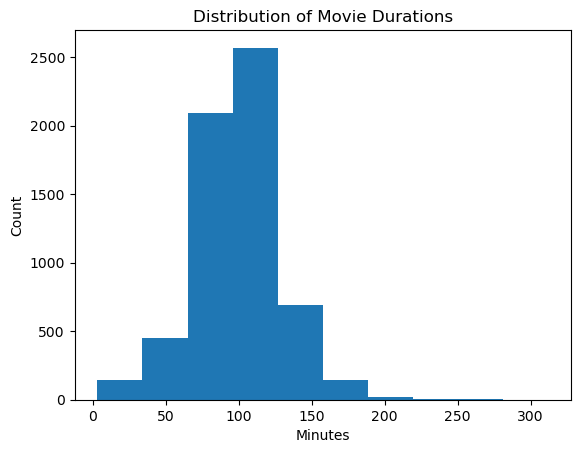

In [46]:
movies['duration'].plot(kind='hist')

plt.title('Distribution of Movie Durations')
plt.xlabel('Minutes')
plt.ylabel('Count')
plt.show()

In [47]:
df.to_csv("cleaned_netflix_data.csv", index=False)